In [ ]:
# Install dependencies
!pip install easyocr
!pip install transformers
!pip install datasets
!pip install jiwer

In [ ]:
# Load IAM-line Dataset
from datasets import load_dataset
ds = load_dataset("Teklia/IAM-line")
print(ds)

# Take the first 30 samples for testing
test_data = ds["test"]
sample_data = test_data.select(range(30))
len(sample_data)

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})


30

In [ ]:
import easyocr
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
import numpy as np

# Load EasyOCR model
easy_reader = easyocr.Reader(["en"], gpu=True)

# Load TrOCR model
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

# Define prediction function
def easy_predict(image_array):
    import cv2
    cv2.imwrite("tmp.png", image_array)
    result = easy_reader.readtext("tmp.png", detail=0)
    return " ".join(result)


def trocr_predict(image_array):
    image = Image.fromarray(image_array)
    if image.mode != "RGB":
        image = image.convert("RGB")

    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    generated_ids = model.generate(pixel_values)
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return text

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Get predictions and ground truth
easy_preds = []
trocr_preds = []
targets = []

for sample in sample_data:
    img = sample["image"]
    gt = sample["text"]

    try:
        easy_preds.append(easy_predict(np.array(img)))
    except:
        easy_preds.append("")

    trocr_preds.append(trocr_predict(np.array(img)))
    targets.append(gt)

In [ ]:
# Calculate CER & WER using jiwer

from jiwer import cer, wer

easy_cer = cer(targets, easy_preds)
easy_wer = wer(targets, easy_preds)

trocr_cer = cer(targets, trocr_preds)
trocr_wer = wer(targets, trocr_preds)

print("EasyOCR CER:", easy_cer)
print("EasyOCR WER:", easy_wer)
print("TrOCR CER:", trocr_cer)
print("TrOCR WER:", trocr_wer)

EasyOCR CER: 0.6657549234135668
EasyOCR WER: 1.0438144329896908
TrOCR CER: 0.08643326039387308
TrOCR WER: 0.2036082474226804


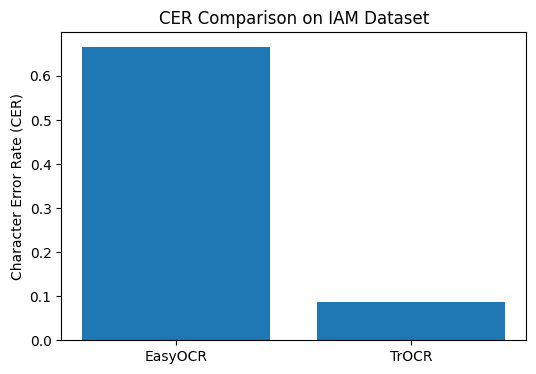

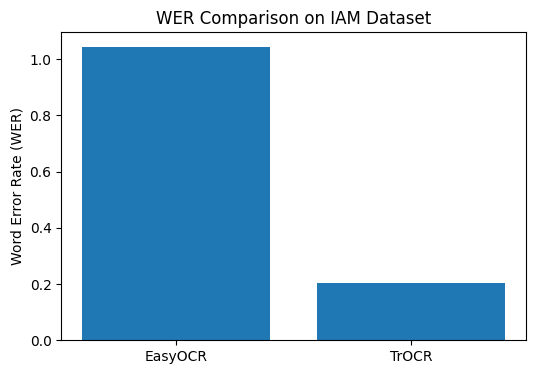

In [ ]:
# Draw charts

import matplotlib.pyplot as plt

labels = ["EasyOCR", "TrOCR"]
cer_scores = [easy_cer, trocr_cer]
wer_scores = [easy_wer, trocr_wer]

plt.figure(figsize=(6,4))
plt.bar(labels, cer_scores)
plt.ylabel("Character Error Rate (CER)")
plt.title("CER Comparison on IAM Dataset")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(labels, wer_scores)
plt.ylabel("Word Error Rate (WER)")
plt.title("WER Comparison on IAM Dataset")
plt.show()